# Buscas cegas


As **buscas cegas** são algoritmos que exploram um espaço de busca **sem utilizar heurísticas** ou informações adicionais sobre qual caminho é melhor.
Eles apenas seguem uma estratégia sistemática para visitar todos os estados possíveis até encontrar a solução.

No contexto do **labirinto**, isso significa que o algoritmo:

* não sabe onde está a saída
* não sabe qual caminho é melhor
* apenas explora os caminhos disponíveis
* evita revisitar posições já exploradas

As duas buscas cegas mais utilizadas são:

* 🔵 Busca em Largura (BFS — Breadth-First Search)
* 🟢 Busca em Profundidade (DFS — Depth-First Search)

---


## 🔵 Busca em Largura — BFS

A **Busca em Largura (BFS)** explora o espaço **nível por nível**, expandindo todos os nós mais próximos antes de avançar para níveis mais profundos.

### Características

* Usa uma **fila (FIFO)**
* Expande como uma **onda** 🌊
* Sempre encontra o **menor caminho** (em grafos não ponderados)
* Consome mais memória

### Intuição

Imagine que você joga uma pedra em um lago. As ondas se expandem uniformemente.
O BFS funciona exatamente assim.

### No labirinto

* Primeiro testa casas próximas
* Depois casas mais distantes
* Até encontrar a saída

### Vantagem

✔ Encontra o caminho mais curto

### Desvantagem

❌ Pode visitar muitos nós

---

In [34]:
# Busca em largura

from collections import deque

def bfs(grafo, inicio):
    visitados = set()
    fila = deque([inicio])

    while fila:
        no = fila.popleft()

        if no not in visitados:
            print(no, end=" ")
            visitados.add(no)

            for vizinho in grafo[no]:
                fila.append(vizinho)

grafo = {
    'A': ['B', 'C'],
    'B': ['D', 'E'],
    'C': ['F', 'G'],
    'D': ['G'],
    'E': [],
    'F': [],
    'G': []
}

bfs(grafo, 'A')

A B C D E F G 


## 🟢 Busca em Profundidade — DFS

A **Busca em Profundidade (DFS)** explora um caminho **até o fim** antes de tentar outro.

### Características

* Usa uma **pilha (LIFO)** ou recursão
* Vai **fundo primeiro** ⬇️
* Usa menos memória
* Não garante menor caminho

### Intuição

Imagine explorar um labirinto sempre escolhendo um corredor e indo até o final.
Se não encontrar saída, você volta e tenta outro.

### No labirinto

* escolhe um caminho
* vai até o fim
* volta (backtracking)
* tenta outro caminho

### Vantagem

✔ Menor uso de memória

### Desvantagem

❌ Pode encontrar caminhos longos

---


In [ ]:
def dfs(grafo, no, visitados=None):
    if visitados is None:
        visitados = set()

    print(no, end=" ")
    visitados.add(no)

    for vizinho in grafo[no]:
        if vizinho not in visitados:
            dfs(grafo, vizinho, visitados)

dfs(grafo, 'A')

A B D E C F G 

---


## Comparação BFS vs DFS

| Característica | BFS        | DFS                 |
| -------------- | ---------- | ------------------- |
| Estrutura      | Fila       | Pilha               |
| Exploração     | Por nível  | Profunda            |
| Menor caminho  | Sim        | Não                 |
| Memória        | Alta       | Baixa               |
| Velocidade     | Mais lenta | Pode ser rápida     |
| Comportamento  | Onda       | Exploração profunda |

---

## Aplicação no Labirinto

No problema do labirinto:

* BFS → encontra o **menor caminho até a saída**
* DFS → encontra **algum caminho**, não necessariamente o menor

Isso permite comparar os algoritmos visualmente durante a execução.

---

## Aplicações Reais

As buscas cegas são usadas em diversos problemas reais:

* 🚗 Sistemas de navegação (GPS)
* 🤖 Robôs autônomos
* 🎮 Inteligência artificial em jogos
* 🌐 Roteamento em redes de computadores
* 📦 Logística e armazéns automatizados
* 🧭 Planejamento de caminhos

---

## Conclusão

* Buscas cegas exploram sem heurística
* BFS expande por níveis e encontra menor caminho
* DFS aprofunda e usa menos memória
* O labirinto é um excelente exemplo didático para comparar os dois algoritmos

# Exemplo de DFS e BFS com Animação

Animações abaixo

In [1]:
!pip install networkx

### Criando o grafo

In [2]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.Graph()

edges = [
    ('A','B'),
    ('A','C'),
    ('B','D'),
    ('B','E'),
    ('C','F'),
    ('C','G')
]

G.add_edges_from(edges)

In [3]:
import time
from IPython.display import clear_output

def desenhar_grafo(G, visitados):

    clear_output(wait=True)

    pos = nx.spring_layout(G, seed=42)

    cores = []
    for node in G.nodes():
        if node in visitados:
            cores.append("red")
        else:
            cores.append("lightblue")

    nx.draw(G, pos,
            with_labels=True,
            node_color=cores,
            node_size=2000,
            font_size=14)

    plt.show()

### BFS

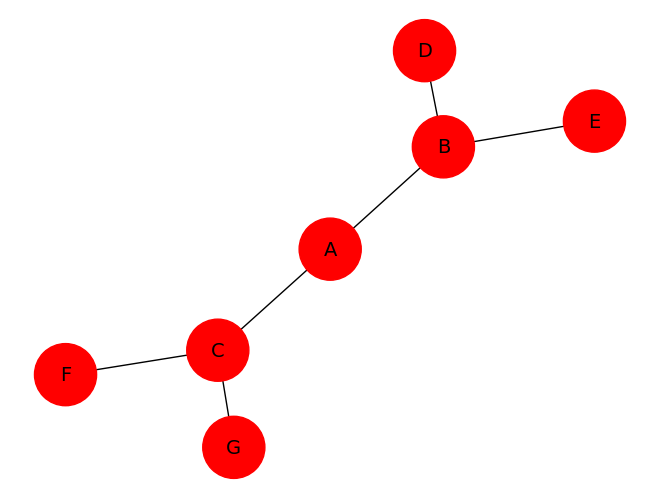

In [20]:
from collections import deque

def bfs_animado(G, inicio):

    fila = deque([inicio])
    visitados = []

    while fila:

        no = fila.popleft()

        if no not in visitados:

            visitados.append(no)

            desenhar_grafo(G, visitados)
            time.sleep(1)

            for vizinho in G.neighbors(no):
                fila.append(vizinho)

bfs_animado(G,'A')

### DFS

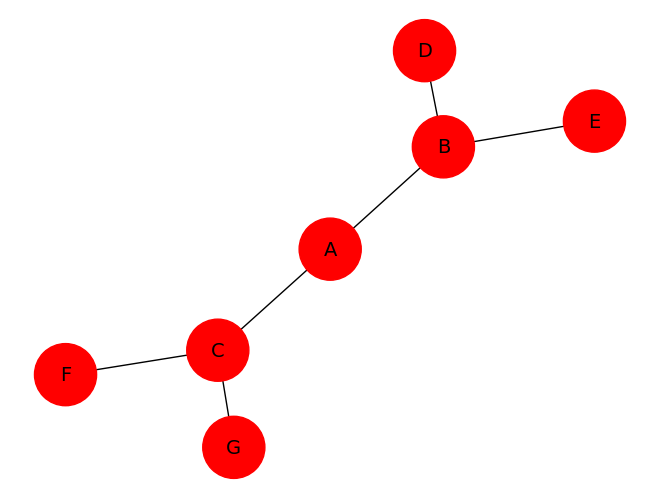

In [21]:
def dfs_animado(G, inicio):

    pilha = [inicio]
    visitados = []

    while pilha:

        no = pilha.pop()

        if no not in visitados:

            visitados.append(no)

            desenhar_grafo(G, visitados)
            time.sleep(1)

            for vizinho in G.neighbors(no):
                pilha.append(vizinho)

dfs_animado(G,'A')

In [7]:
pos = {
'A':(0,3),
'B':(-1,2),
'C':(1,2),
'D':(-1.5,1),
'E':(-0.5,1),
'F':(0.5,1),
'G':(1.5,1)
}

# Exemplo DFS e BFS com Animação

In [9]:
!pip install networkx

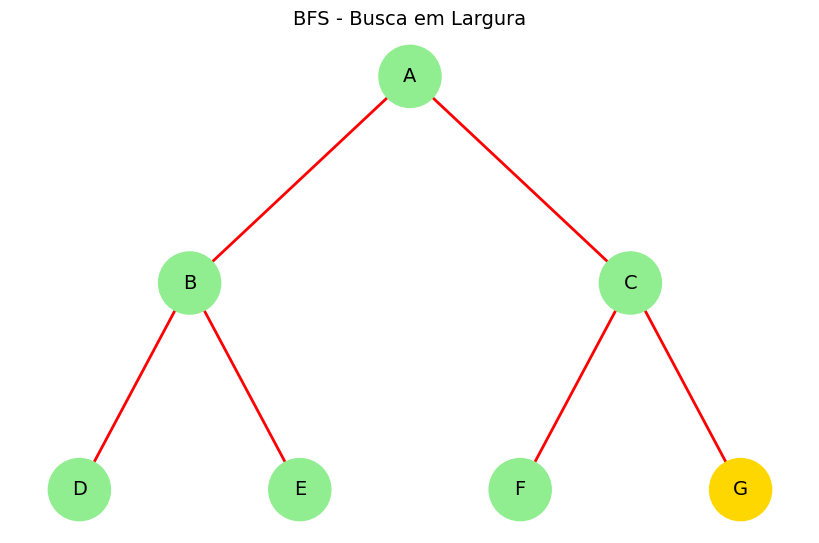

In [10]:
import networkx as nx
import matplotlib.pyplot as plt
import time
from collections import deque
from IPython.display import clear_output

# Criando o grafo
G = nx.Graph()
edges = [
    ('A','B'),
    ('A','C'),
    ('B','D'),
    ('B','E'),
    ('C','F'),
    ('C','G')
]
G.add_edges_from(edges)

# Layout fixo (fica bonito como árvore)
pos = {
    'A': (0,3),
    'B': (-2,2),
    'C': (2,2),
    'D': (-3,1),
    'E': (-1,1),
    'F': (1,1),
    'G': (3,1)
}

def desenhar(G, visitados, atual, arestas_visitadas):

    clear_output(wait=True)
    plt.figure(figsize=(8,5))

    # cores dos nós
    cores_nos = []
    for no in G.nodes():
        if no == atual:
            cores_nos.append("#FFD700")  # amarelo (atual)
        elif no in visitados:
            cores_nos.append("#90EE90")  # verde (visitado)
        else:
            cores_nos.append("#ADD8E6")  # azul (não visitado)

    # cores das arestas
    cores_arestas = []
    for edge in G.edges():
        if edge in arestas_visitadas or (edge[1],edge[0]) in arestas_visitadas:
            cores_arestas.append("red")
        else:
            cores_arestas.append("gray")

    nx.draw(
        G,
        pos,
        with_labels=True,
        node_color=cores_nos,
        edge_color=cores_arestas,
        node_size=2000,
        font_size=14,
        width=2
    )

    plt.title("BFS - Busca em Largura", fontsize=14)
    plt.show()


def bfs_animado(G, inicio):

    fila = deque([inicio])
    visitados = []
    arestas_visitadas = []

    while fila:

        atual = fila.popleft()

        if atual not in visitados:

            visitados.append(atual)
            desenhar(G, visitados, atual, arestas_visitadas)
            time.sleep(1)

            for vizinho in G.neighbors(atual):

                if vizinho not in visitados:
                    arestas_visitadas.append((atual, vizinho))
                    fila.append(vizinho)

                    desenhar(G, visitados, atual, arestas_visitadas)
                    time.sleep(0.6)


bfs_animado(G, 'A')

### Exemplo DFS

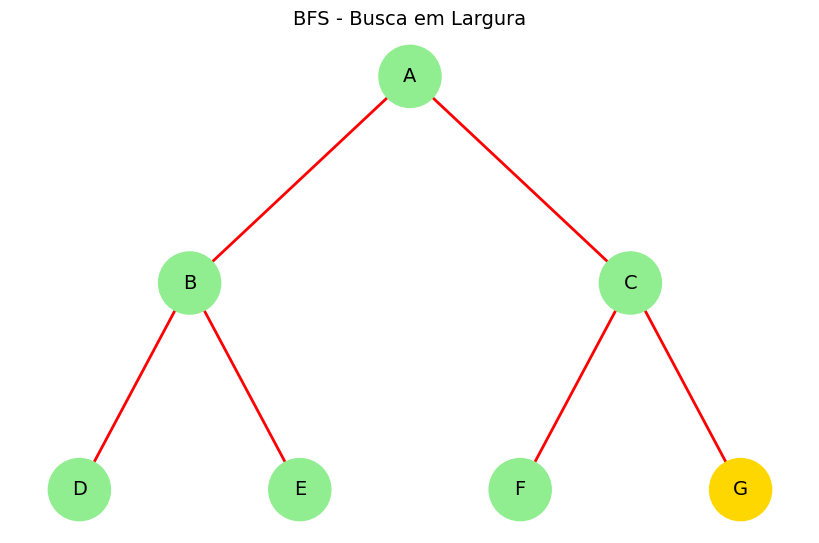

In [12]:
def dfs_animado(G, inicio):

    pilha = [inicio]
    visitados = []
    arestas_visitadas = []

    while pilha:

        atual = pilha.pop()

        if atual not in visitados:

            visitados.append(atual)
            desenhar(G, visitados, atual, arestas_visitadas)
            time.sleep(1)

            for vizinho in reversed(list(G.neighbors(atual))):

                if vizinho not in visitados:
                    arestas_visitadas.append((atual, vizinho))
                    pilha.append(vizinho)

                    desenhar(G, visitados, atual, arestas_visitadas)
                    time.sleep(0.6)


dfs_animado(G, 'A')

# Exemplo de animação

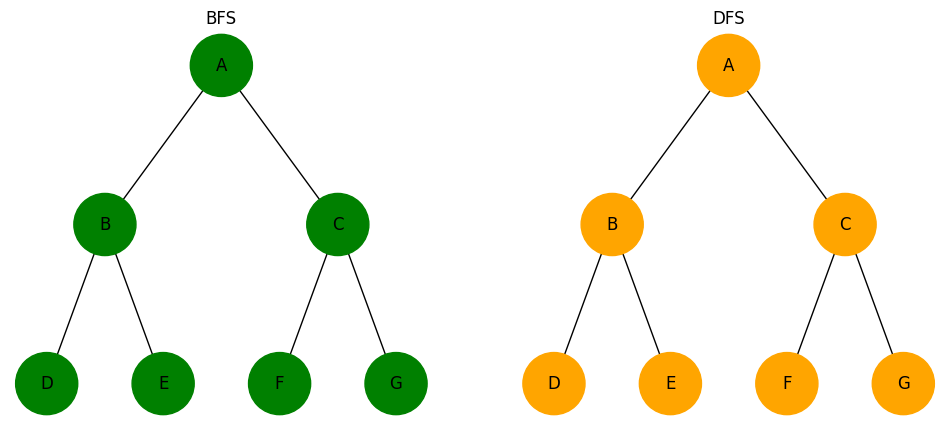

In [13]:
import networkx as nx
import matplotlib.pyplot as plt
import time
from collections import deque
from IPython.display import clear_output

G = nx.Graph()
edges = [
    ('A','B'),('A','C'),
    ('B','D'),('B','E'),
    ('C','F'),('C','G')
]
G.add_edges_from(edges)

pos = {
    'A': (0,3),
    'B': (-2,2),
    'C': (2,2),
    'D': (-3,1),
    'E': (-1,1),
    'F': (1,1),
    'G': (3,1)
}

def desenhar_duplo(vis_bfs, vis_dfs):
    clear_output(wait=True)
    plt.figure(figsize=(12,5))

    # BFS
    plt.subplot(1,2,1)
    cores = ["green" if n in vis_bfs else "lightblue" for n in G.nodes()]
    nx.draw(G,pos,with_labels=True,node_color=cores,node_size=2000)
    plt.title("BFS")

    # DFS
    plt.subplot(1,2,2)
    cores = ["orange" if n in vis_dfs else "lightblue" for n in G.nodes()]
    nx.draw(G,pos,with_labels=True,node_color=cores,node_size=2000)
    plt.title("DFS")

    plt.show()

def comparar():
    fila = deque(['A'])
    pilha = ['A']

    vis_bfs = []
    vis_dfs = []

    while fila or pilha:

        if fila:
            n = fila.popleft()
            if n not in vis_bfs:
                vis_bfs.append(n)
                for v in G.neighbors(n):
                    fila.append(v)

        if pilha:
            n = pilha.pop()
            if n not in vis_dfs:
                vis_dfs.append(n)
                for v in reversed(list(G.neighbors(n))):
                    pilha.append(v)

        desenhar_duplo(vis_bfs, vis_dfs)
        time.sleep(1)

comparar()

# Exemplo labirinto

## Aplicacao de um DFS

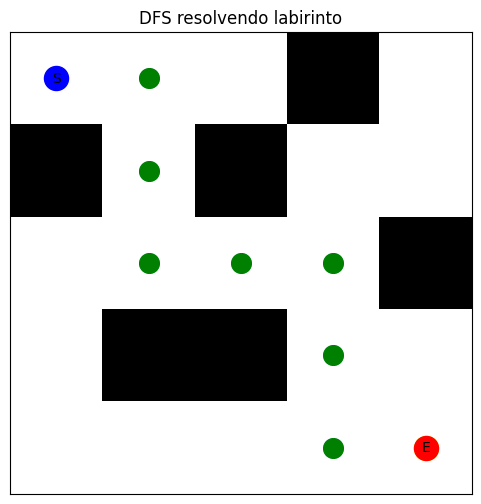

Saída encontrada!


[(0, 0), (0, 1), (1, 1), (2, 1), (2, 2), (2, 3), (3, 3), (4, 3), (4, 4)]

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import time
from IPython.display import clear_output

lab = np.array([
[0,0,0,1,0],
[1,0,1,0,0],
[0,0,0,0,1],
[0,1,1,0,0],
[0,0,0,0,0]
])

inicio = (0,0)
saida = (4,4)

def dfs_labirinto():

    pilha = [(inicio, [inicio])]
    visitados = set()

    while pilha:

        (x,y), caminho = pilha.pop()

        if (x,y) in visitados:
            continue

        visitados.add((x,y))

        clear_output(wait=True)
        plt.figure(figsize=(6,6))

        # desenha labirinto
        plt.imshow(lab, cmap="gray_r")

        # visitados
        for vx,vy in visitados:
            plt.scatter(vy, vx, color="lightblue", s=200)

        # caminho atual
        for cx,cy in caminho:
            plt.scatter(cy, cx, color="green", s=200)

        # posição atual
        plt.scatter(y, x, color="yellow", s=300)

        # início
        plt.scatter(inicio[1], inicio[0], color="blue", s=300)
        plt.text(inicio[1], inicio[0], "S", ha='center', va='center')

        # saída
        plt.scatter(saida[1], saida[0], color="red", s=300)
        plt.text(saida[1], saida[0], "E", ha='center', va='center')

        plt.title("DFS resolvendo labirinto")
        plt.xticks([])
        plt.yticks([])
        plt.show()

        time.sleep(0.3)

        if (x,y) == saida:
            print("Saída encontrada!")
            return caminho

        # movimentos (ordem define comportamento DFS)
        for dx,dy in reversed([(1,0),(-1,0),(0,1),(0,-1)]):

            nx = x + dx
            ny = y + dy

            if 0 <= nx < lab.shape[0] and 0 <= ny < lab.shape[1]:
                if lab[nx,ny] == 0:
                    pilha.append(((nx,ny), caminho + [(nx,ny)]))

    print("Sem saída")

dfs_labirinto()

## Aplicacao de um BFS

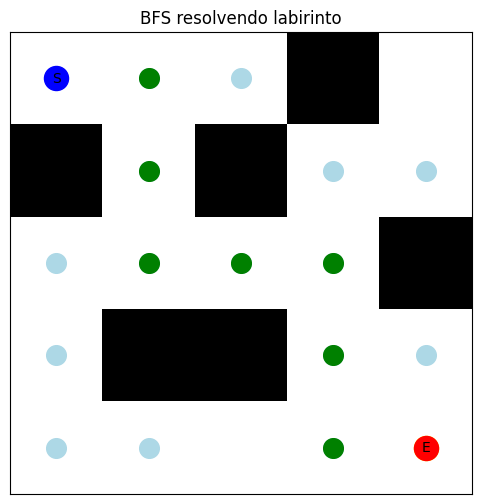

Saída encontrada!


[(0, 0), (0, 1), (1, 1), (2, 1), (2, 2), (2, 3), (3, 3), (4, 3), (4, 4)]

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import time
from collections import deque
from IPython.display import clear_output

lab = np.array([
[0,0,0,1,0],
[1,0,1,0,0],
[0,0,0,0,1],
[0,1,1,0,0],
[0,0,0,0,0]
])

inicio = (0,0)
saida = (4,4)

def bfs_labirinto():

    fila = deque([(inicio, [inicio])])
    visitados = set()

    while fila:

        (x,y), caminho = fila.popleft()

        if (x,y) in visitados:
            continue

        visitados.add((x,y))

        clear_output(wait=True)
        plt.figure(figsize=(6,6))

        # desenha labirinto
        plt.imshow(lab, cmap="gray_r")

        # visitados (onda BFS)
        for vx,vy in visitados:
            plt.scatter(vy, vx, color="lightblue", s=200)

        # caminho atual
        for cx,cy in caminho:
            plt.scatter(cy, cx, color="green", s=200)

        # posição atual
        plt.scatter(y, x, color="yellow", s=300)

        # início
        plt.scatter(inicio[1], inicio[0], color="blue", s=300)
        plt.text(inicio[1], inicio[0], "S", ha='center', va='center')

        # saída
        plt.scatter(saida[1], saida[0], color="red", s=300)
        plt.text(saida[1], saida[0], "E", ha='center', va='center')

        plt.title("BFS resolvendo labirinto")
        plt.xticks([])
        plt.yticks([])
        plt.show()

        time.sleep(0.2)

        if (x,y) == saida:
            print("Saída encontrada!")
            return caminho

        # movimentos
        for dx,dy in [(1,0),(-1,0),(0,1),(0,-1)]:

            nx = x + dx
            ny = y + dy

            if 0 <= nx < lab.shape[0] and 0 <= ny < lab.shape[1]:
                if lab[nx,ny] == 0:
                    fila.append(((nx,ny), caminho + [(nx,ny)]))

    print("Sem saída")

bfs_labirinto()

## Comparação

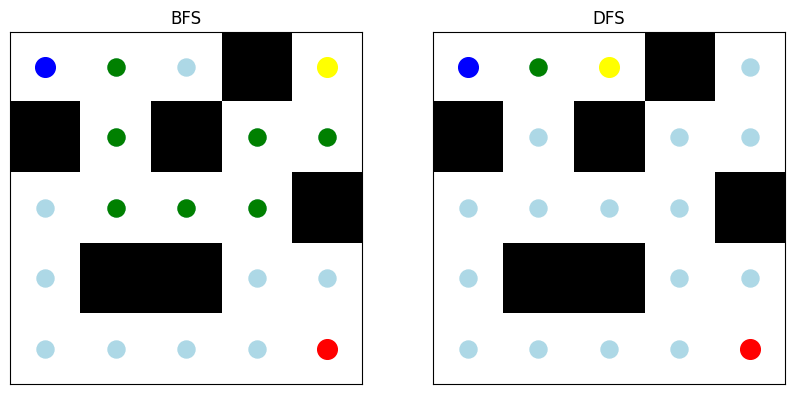

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import time
from collections import deque
from IPython.display import clear_output

lab = np.array([
[0,0,0,1,0],
[1,0,1,0,0],
[0,0,0,0,1],
[0,1,1,0,0],
[0,0,0,0,0]
])

inicio = (0,0)
saida = (4,4)

def desenhar(bfs_state, dfs_state):

    clear_output(wait=True)
    plt.figure(figsize=(10,5))

    # ----- BFS -----
    plt.subplot(1,2,1)
    plt.imshow(lab, cmap="gray_r")

    visitados, caminho, atual = bfs_state

    for x,y in visitados:
        plt.scatter(y,x,color="lightblue",s=150)

    for x,y in caminho:
        plt.scatter(y,x,color="green",s=150)

    if atual:
        plt.scatter(atual[1],atual[0],color="yellow",s=200)

    plt.scatter(inicio[1],inicio[0],color="blue",s=200)
    plt.scatter(saida[1],saida[0],color="red",s=200)

    plt.title("BFS")
    plt.xticks([])
    plt.yticks([])

    # ----- DFS -----
    plt.subplot(1,2,2)
    plt.imshow(lab, cmap="gray_r")

    visitados, caminho, atual = dfs_state

    for x,y in visitados:
        plt.scatter(y,x,color="lightblue",s=150)

    for x,y in caminho:
        plt.scatter(y,x,color="green",s=150)

    if atual:
        plt.scatter(atual[1],atual[0],color="yellow",s=200)

    plt.scatter(inicio[1],inicio[0],color="blue",s=200)
    plt.scatter(saida[1],saida[0],color="red",s=200)

    plt.title("DFS")
    plt.xticks([])
    plt.yticks([])

    plt.show()


def comparar_bfs_dfs():

    fila = deque([(inicio,[inicio])])
    pilha = [(inicio,[inicio])]

    visitados_bfs = set()
    visitados_dfs = set()

    bfs_state = ([],[],None)
    dfs_state = ([],[],None)

    while fila or pilha:

        # BFS passo
        if fila:
            (x,y), caminho = fila.popleft()

            if (x,y) not in visitados_bfs:
                visitados_bfs.add((x,y))

                bfs_state = (visitados_bfs.copy(), caminho, (x,y))

                if (x,y) != saida:
                    for dx,dy in [(1,0),(-1,0),(0,1),(0,-1)]:
                        nx,ny = x+dx,y+dy
                        if 0<=nx<5 and 0<=ny<5 and lab[nx,ny]==0:
                            fila.append(((nx,ny), caminho+[(nx,ny)]))

        # DFS passo
        if pilha:
            (x,y), caminho = pilha.pop()

            if (x,y) not in visitados_dfs:
                visitados_dfs.add((x,y))

                dfs_state = (visitados_dfs.copy(), caminho, (x,y))

                if (x,y) != saida:
                    for dx,dy in reversed([(1,0),(-1,0),(0,1),(0,-1)]):
                        nx,ny = x+dx,y+dy
                        if 0<=nx<5 and 0<=ny<5 and lab[nx,ny]==0:
                            pilha.append(((nx,ny), caminho+[(nx,ny)]))

        desenhar(bfs_state, dfs_state)
        time.sleep(0.3)

comparar_bfs_dfs()

---

# Exemplo labirinto (mais caminhos possíveis)

## Exemplo matriz gigante

In [32]:
import numpy as np

lab = np.array([
[0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0],
[1,1,0,1,1,0,1,1,1,0,1,0,1,1,1,1,0,1,0,0],
[0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1],
[0,1,1,1,1,1,1,0,1,1,1,1,1,0,1,0,1,1,0,0],
[0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0],
[1,1,1,1,1,0,1,1,1,1,1,0,1,1,1,0,1,0,1,0],
[0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0],
[0,1,1,0,1,1,1,1,1,0,1,1,1,0,1,1,1,0,1,0],
[0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0],
[1,0,1,1,1,1,1,0,1,1,1,0,1,1,1,0,1,1,1,0],
[0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,1,0],
[0,1,1,1,1,0,1,1,1,0,1,1,1,1,1,1,1,0,1,0],
[0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0],
[1,1,1,0,1,1,1,0,1,1,1,1,1,1,1,0,1,1,1,0],
[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
[0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0],
[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
[0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0],
[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
[0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0]
])

inicio = (0,0)
saida = (19,19)

### Gera matriz fixa

### Gera caminho aleatóriamente

In [ ]:
import numpy as np

np.random.seed(42)

tamanho = 50

lab = np.random.choice([0,1], size=(tamanho,tamanho), p=[0.7,0.3])

# garantir início e saída livres
lab[0,0] = 0
lab[tamanho-1,tamanho-1] = 0

inicio = (0,0)
saida = (tamanho-1,tamanho-1)

print("Tamanho:", lab.shape)

### Garante um caminho

In [27]:
import numpy as np

tamanho = 40
lab = np.ones((tamanho,tamanho))

# criar caminho
for i in range(tamanho):
    lab[i,0] = 0

for j in range(tamanho):
    lab[tamanho-1,j] = 0

# adicionar ruído
np.random.seed(0)
ruido = np.random.choice([0,1], size=(tamanho,tamanho), p=[0.8,0.2])
lab = np.minimum(lab, ruido)

lab[0,0] = 0
lab[tamanho-1,tamanho-1] = 0

inicio = (0,0)
saida = (tamanho-1,tamanho-1)

### Resolvendo com BFS

In [29]:
def bfs_labirinto():

    fila = deque([(inicio, [inicio])])
    visitados = set()

    while fila:

        (x,y), caminho = fila.popleft()

        if (x,y) in visitados:
            continue

        visitados.add((x,y))

        clear_output(wait=True)
        plt.figure(figsize=(12,12))

        # desenha labirinto
        plt.imshow(lab, cmap="gray_r")

        # visitados (onda BFS)
        for vx,vy in visitados:
            plt.scatter(vy, vx, color="lightblue", s=200)

        # caminho atual
        for cx,cy in caminho:
            plt.scatter(cy, cx, color="green", s=200)

        # posição atual
        plt.scatter(y, x, color="yellow", s=300)

        # início
        plt.scatter(inicio[1], inicio[0], color="blue", s=300)
        plt.text(inicio[1], inicio[0], "S", ha='center', va='center')

        # saída
        plt.scatter(saida[1], saida[0], color="red", s=300)
        plt.text(saida[1], saida[0], "E", ha='center', va='center')

        plt.title("BFS resolvendo labirinto")
        plt.xticks([])
        plt.yticks([])
        plt.show()

        time.sleep(0.2)

        if (x,y) == saida:
            print("Saída encontrada!")
            return caminho

        # movimentos
        for dx,dy in [(1,0),(-1,0),(0,1),(0,-1)]:

            nx = x + dx
            ny = y + dy

            if 0 <= nx < lab.shape[0] and 0 <= ny < lab.shape[1]:
                if lab[nx,ny] == 0:
                    fila.append(((nx,ny), caminho + [(nx,ny)]))

    print("Sem saída")

bfs_labirinto()

KeyboardInterrupt: 

### Resolvendo com DFS

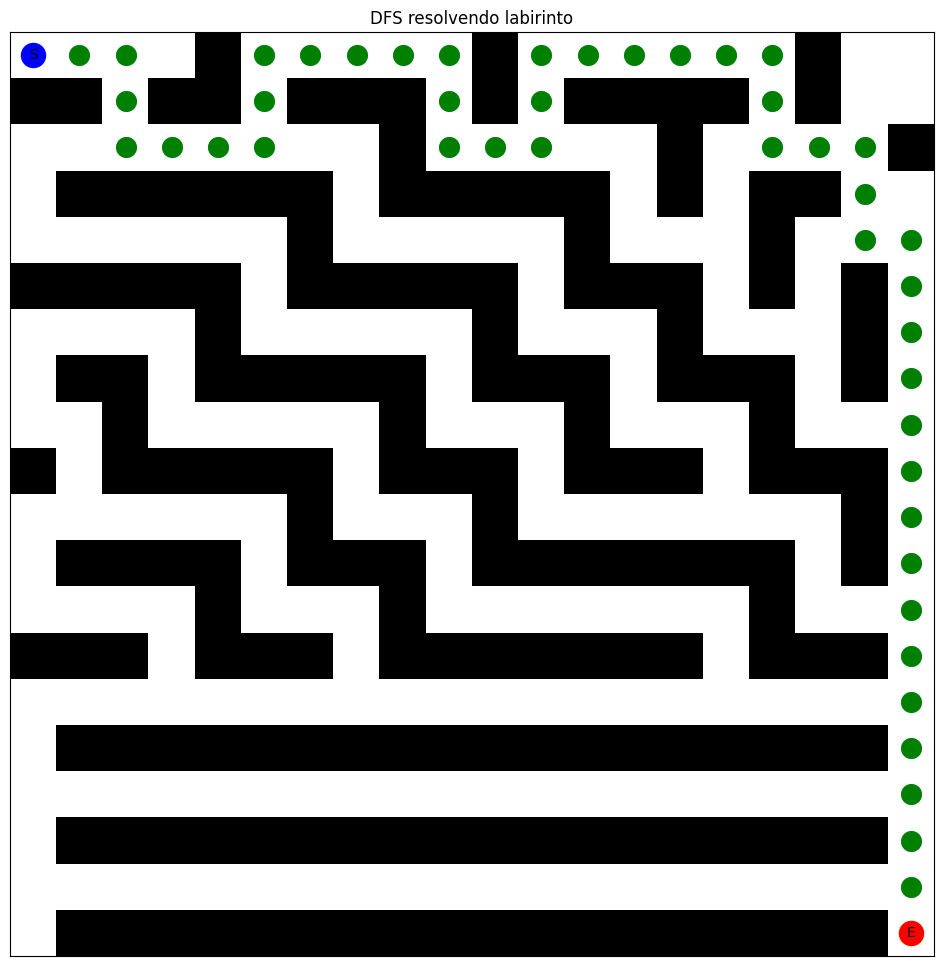

Saída encontrada!


[(0, 0),
 (0, 1),
 (0, 2),
 (1, 2),
 (2, 2),
 (2, 3),
 (2, 4),
 (2, 5),
 (1, 5),
 (0, 5),
 (0, 6),
 (0, 7),
 (0, 8),
 (0, 9),
 (1, 9),
 (2, 9),
 (2, 10),
 (2, 11),
 (1, 11),
 (0, 11),
 (0, 12),
 (0, 13),
 (0, 14),
 (0, 15),
 (0, 16),
 (1, 16),
 (2, 16),
 (2, 17),
 (2, 18),
 (3, 18),
 (4, 18),
 (4, 19),
 (5, 19),
 (6, 19),
 (7, 19),
 (8, 19),
 (9, 19),
 (10, 19),
 (11, 19),
 (12, 19),
 (13, 19),
 (14, 19),
 (15, 19),
 (16, 19),
 (17, 19),
 (18, 19),
 (19, 19)]

In [33]:
def dfs_labirinto():

    pilha = [(inicio, [inicio])]
    visitados = set()

    while pilha:

        (x,y), caminho = pilha.pop()

        if (x,y) in visitados:
            continue

        visitados.add((x,y))

        clear_output(wait=True)
        plt.figure(figsize=(12,12))

        # desenha labirinto
        plt.imshow(lab, cmap="gray_r")

        # visitados
        for vx,vy in visitados:
            plt.scatter(vy, vx, color="lightblue", s=200)

        # caminho atual
        for cx,cy in caminho:
            plt.scatter(cy, cx, color="green", s=200)

        # posição atual
        plt.scatter(y, x, color="yellow", s=300)

        # início
        plt.scatter(inicio[1], inicio[0], color="blue", s=300)
        plt.text(inicio[1], inicio[0], "S", ha='center', va='center')

        # saída
        plt.scatter(saida[1], saida[0], color="red", s=300)
        plt.text(saida[1], saida[0], "E", ha='center', va='center')

        plt.title("DFS resolvendo labirinto")
        plt.xticks([])
        plt.yticks([])
        plt.show()

        time.sleep(0.3)

        if (x,y) == saida:
            print("Saída encontrada!")
            return caminho

        # movimentos (ordem define comportamento DFS)
        for dx,dy in reversed([(1,0),(-1,0),(0,1),(0,-1)]):

            nx = x + dx
            ny = y + dy

            if 0 <= nx < lab.shape[0] and 0 <= ny < lab.shape[1]:
                if lab[nx,ny] == 0:
                    pilha.append(((nx,ny), caminho + [(nx,ny)]))

    print("Sem saída")

dfs_labirinto()